In [7]:
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import torch
from flonacomldft.utils.io_utils import (
    load_from_pickle, load_zmat_csv, load_csv_file, get_path, 
)
from flonacomldft.utils.data_processing import get_mix_data
# from flonacomldft.models import Uncentered_MLP
from flonacomldft.models.mixture import Mixture, get_models
from flonacomldft.models.real_nvp import RealNVP_MLP, Angles_mapping
from flonacomldft.collective_variables import get_CVs

In [8]:
data_path = get_path()
data_path

'/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft/database/'

It looks like not all the angles are in between $[- \pi, \pi]$, is that ok? 

Angles range: 6.126550674438477
Angles range: 4.249532222747803


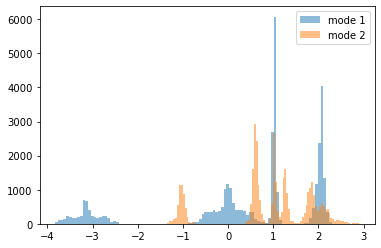

In [9]:
x_rads = []
for mode_label in [1 ,2]:
    df = pd.read_csv(get_path() + "is{:d}_lcao_zmat.csv".format(mode_label))
    U = df.energies
    X = df.drop(["energies"], axis=1)

    n = -1

    x_rad = torch.from_numpy(X[:n].to_numpy()).float()
    U_rad = torch.from_numpy(U[:n].to_numpy()).float()
    x_rads.append(x_rad)
    
    print('Angles range:', (x_rad[:, 5:].max() - x_rad[:, 5:].min()).item())

    _ = plt.hist(x_rad[:,5:].numpy().flatten(), bins=100, alpha=0.5, label="mode {:d}".format(mode_label))

plt.legend()

Conversely we can center before taking the tan and not use the mean in the covariance. 

Angles range: 1.664990782737732
Angles range: 1.4062482118606567


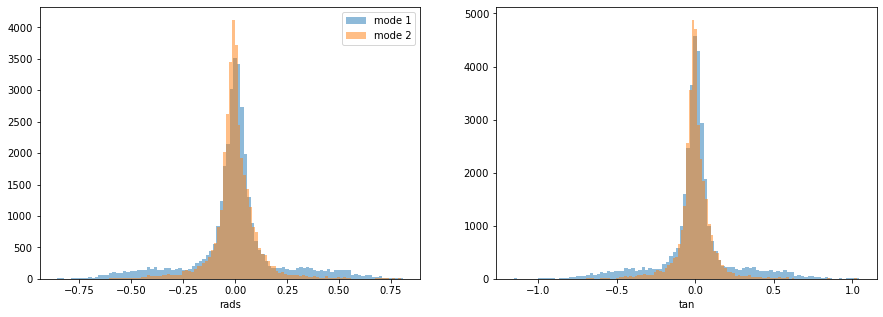

In [10]:
x_rad_centereds = []
x_rad_centers = []

plt.figure('', figsize=(15, 5))
axs = [plt.subplot(1, 2, i+1) for i in range(2)]

for mode_label in [1 ,2]:
    df = pd.read_csv(get_path() + "is{:d}_lcao_zmat.csv".format(mode_label))
    U = df.energies
    X = df.drop(["energies"], axis=1)

    n = -1

    x_rad = torch.from_numpy(X[:n].to_numpy()).float()
    U_rad = torch.from_numpy(U[:n].to_numpy()).float()
    x_rad_center = x_rad.mean(dim=0)
    x_rad_centered = x_rad - x_rad_center

    x_rad_centers.append(x_rad_center)
    x_rad_centereds.append(x_rad_centered)
    
    print('Angles range:', (x_rad_centered[:, 5:].max() - x_rad_centered[:, 5:].min()).item())

    plt.sca(axs[0])
    _ = plt.hist(x_rad_centered[:,5:].numpy().flatten(), bins=100, alpha=0.5, label="mode {:d}".format(mode_label))
    plt.xlabel('rads')
    plt.legend()

    plt.sca(axs[1])
    _ = plt.hist(x_rad_centered[:,5:].tan().numpy().flatten(), bins=100, alpha=0.5, label="mode {:d}".format(mode_label))
    plt.xlabel('tan')

# RealNVP

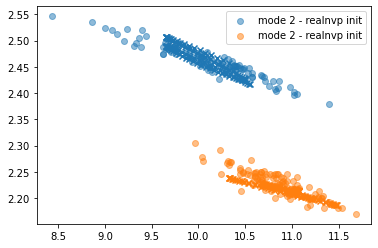

In [27]:
for i in range(2):
    x_real_centered, _ = Angles_mapping().rads_to_reals(x_rad_centereds[i])
    cov_real = torch.cov(x_real_centered.T)

    centering_args = {"cov": cov_real, "mean": x_rad_centers[i]}
    model = RealNVP_MLP(
        12,
        3,
        1,
        init_weight_scale=1e-3,
        centering_args=centering_args,
    )

    x_sample = model.sample(100)
    x_sample_cv = np.array(get_CVs(x_sample)).T
    plt.scatter(x_sample_cv[:, 0], x_sample_cv[:, 1], label="mode {:d} - realnvp init".format(mode_label), c='C{:d}'.format(i), alpha=0.5)
    x_rad_cv = np.array(get_CVs(x_rads[i][:100])).T
    plt.scatter(x_rad_cv[:, 0], x_rad_cv[:, 1], marker='x', c='C{:d}'.format(i))
plt.legend()